# Text Analytics Coursework (Group 37 - Task 2)



# Axis 1-B: LLM-Based Approach (Fine-tuned BERT): 
##### Instead of a general LLM, use a Fine-tuned BioBERT or PubMedBERT LLM Model.


Since the current `gold_label` distribution includes a high proportion of `NONE` and `MIXED` labels, for LLM-Based Approach, we restrict the dataset to unambiguous P/I/O only sentences for the initial experiments. This supports a fair comparison across model axes by reducing label ambiguity that could otherwise blur the distinction between P, I, and O.


In [167]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [168]:
# # For Google Colab

# import os
# from google.colab import drive, userdata

# drive.mount('/content/drive')

# base_project_path = "/content/drive/MyDrive/AITA_Group_Project"

# if not os.path.exists(base_project_path):
#     os.makedirs(base_project_path)

# os.chdir(base_project_path)

# GIT_REPO = "AITA-Group37-Task2"
# repo_path = os.path.join(base_project_path, GIT_REPO)

# if not os.path.exists(repo_path):
#     GIT_TOKEN = userdata.get('GITHUB_TOKEN')
#     GIT_USER = "SBL-97"
#     !git clone https://{GIT_TOKEN}@github.com/{GIT_USER}/{GIT_REPO}.git
# else:
#   pass

# GIT_REPO = "notebooks"
# repo_final_path = os.path.join(repo_path, GIT_REPO)
# os.chdir(repo_final_path)
# !git branch

In [169]:
sentence_records_df = pd.read_csv("../outputs/sentence_records_df.csv")
sentence_test_records_df = pd.read_csv("../outputs/sentence_test_records_df.csv")

In [170]:
train_pio = sentence_records_df[sentence_records_df["gold_label"].isin(["P","I","O"])].copy()
test_pio  = sentence_test_records_df[sentence_test_records_df["gold_label"].isin(["P","I","O"])].copy()

print(f"Train_PIO_Label_Count: {train_pio["gold_label"].value_counts()}\n")
print(f"Test_PIO_Label_Count: {test_pio["gold_label"].value_counts()}")

Train_PIO_Label_Count: gold_label
O    10669
I     5966
P     2824
Name: count, dtype: int64

Test_PIO_Label_Count: gold_label
O    431
I    289
P    126
Name: count, dtype: int64


In [171]:
train_texts = train_pio["sentence_text"].tolist().copy()
train_labels = train_pio["gold_label"].tolist().copy()

test_texts = test_pio["sentence_text"].tolist().copy()
test_labels = test_pio["gold_label"].tolist().copy()

In [172]:
train_texts[:5]

['The drug combination and administration periods in the PPI group were LPZ 30 mg, CAM 400 mg, MTZ 500 mg (LCM group).',
 'The ranitidine group received RNT 300 mg, CAM 400 mg, MTZ 500 mg (RCM group).',
 'Pre-operative short-term pulmonary rehabilitation for patients of chronic obstructive pulmonary disease undergoing coronary artery bypass graft surgery.',
 'The role of pre-operative short-term pulmonary rehabilitation in patients with chronic obstructive pulmonary disease who undergo coronary artery bypass graft surgery has been assessed for the first time prospectively.',
 'Pre-operative and post-operative peak expiratory flow rate, inspiratory capacity, post-operative ventilation time, post-operative pulmonary complication and hospital stay were determined in both the groups.']

In [173]:
train_labels[:5]

['I', 'I', 'I', 'I', 'O']

### A) Embedding labels with unsupervised models

In [ ]:
import torch, numpy as np
from transformers import AutoTokenizer, AutoModel, DataCollatorWithPadding

def mean_pool(last_hidden_state, attention_mask):
    mask = attention_mask.unsqueeze(-1).float()
    return (last_hidden_state * mask).sum(dim=1) / mask.sum(dim=1).clamp(min=1e-9)

@torch.no_grad()
def encode_sentences(sentences, model_name, batch_size=32, max_length=128):
    device = "mps" if torch.backends.mps.is_built() else "cuda" if torch.cuda.is_available() else "cpu"
    tok = AutoTokenizer.from_pretrained(model_name)
    model = AutoModel.from_pretrained(model_name).to(device).eval()

    vecs = []
    for i in range(0, len(sentences), batch_size):
        batch = sentences[i:i+batch_size]
        enc = tok(batch, padding=True, truncation=True, max_length=max_length, return_tensors="pt").to(device)
        out = model(**enc)
        emb = mean_pool(out.last_hidden_state, enc["attention_mask"])
        vecs.append(emb.cpu().numpy())
    return np.vstack(vecs)

MODELS = {
    "BERT": "bert-base-uncased",
    "BioBERT": "dmis-lab/biobert-base-cased-v1.2",
    "PubMedBERT": "microsoft/BiomedNLP-Pub"
    "BERT-base-uncased-abstract",
    "ModernBERT": "answerdotai/ModernBERT-base",
    "BioClinical_ModernBERT": "thomas-sounack/BioClinical-ModernBERT-base",
}

In [175]:
import os, numpy as np

os.makedirs("../outputs/Axis1B/embeddings_axis1B", exist_ok=True)

def encode_and_save(sentences, tag, model_name, split_name, batch_size=16, max_length=128):
    out_path = f"../outputs/Axis1B/embeddings_axis1B/{split_name}_{tag}_meanpool.npy"
    if os.path.exists(out_path):
        print("Already exists, skipping:", out_path)
        return np.load(out_path)

    X = encode_sentences(sentences, model_name, batch_size=batch_size, max_length=max_length)
    np.save(out_path, X)
    print("Saved:", out_path, X.shape)
    return X

X_bert = encode_and_save(train_texts, "BERT", MODELS["BERT"], "train_pio", batch_size=16, max_length=64)

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: bert-base-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Saved: ../outputs/Axis1B/embeddings_axis1B/train_pio_BERT_meanpool.npy (19459, 768)


In [176]:
X_pub = encode_and_save(train_texts, "PubMedBERT", MODELS["PubMedBERT"], "train_pio", batch_size=16, max_length=64)

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: microsoft/BiomedNLP-PubMedBERT-base-uncased-abstract
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.decoder.bias               | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.decoder.weight             | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Saved: ../outputs/Axis1B/embeddings_axis1B/train_pio_PubMedBERT_meanpool.npy (19459, 768)


In [177]:
X_bio = encode_and_save(train_texts, "BioBERT", MODELS["BioBERT"], "train_pio", batch_size=16, max_length=64)

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: dmis-lab/biobert-base-cased-v1.2
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.decoder.bias               | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.decoder.weight             | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Saved: ../outputs/Axis1B/embeddings_axis1B/train_pio_BioBERT_meanpool.npy (19459, 768)


In [178]:
X_mod_bert = encode_and_save(train_texts, "ModernBERT", MODELS["ModernBERT"], "train_pio", batch_size=16, max_length=64)

Loading weights:   0%|          | 0/134 [00:00<?, ?it/s]

ModernBertModel LOAD REPORT from: answerdotai/ModernBERT-base
Key               | Status     |  | 
------------------+------------+--+-
head.dense.weight | UNEXPECTED |  | 
decoder.bias      | UNEXPECTED |  | 
head.norm.weight  | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Saved: ../outputs/Axis1B/embeddings_axis1B/train_pio_ModernBERT_meanpool.npy (19459, 768)


In [179]:
X_biocli_mod_bert = encode_and_save(train_texts, "BioClinical_ModernBERT", MODELS["BioClinical_ModernBERT"], "train_pio", batch_size=16, max_length=64)

Loading weights:   0%|          | 0/134 [00:00<?, ?it/s]

ModernBertModel LOAD REPORT from: thomas-sounack/BioClinical-ModernBERT-base
Key               | Status     |  | 
------------------+------------+--+-
head.dense.weight | UNEXPECTED |  | 
decoder.bias      | UNEXPECTED |  | 
head.norm.weight  | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Saved: ../outputs/Axis1B/embeddings_axis1B/train_pio_BioClinical_ModernBERT_meanpool.npy (19459, 768)


In [180]:
import numpy as np
X_bert = np.load("../outputs/Axis1B/embeddings_axis1B/train_pio_BERT_meanpool.npy")
X_pub  = np.load("../outputs/Axis1B/embeddings_axis1B/train_pio_PubMedBERT_meanpool.npy")
X_bio  = np.load("../outputs/Axis1B/embeddings_axis1B/train_pio_BioBERT_meanpool.npy")
X_mod_bert  = np.load("../outputs/Axis1B/embeddings_axis1B/train_pio_ModernBERT_meanpool.npy")
X_biocli_mod_bert  = np.load("../outputs/Axis1B/embeddings_axis1B/train_pio_BioClinical_ModernBERT_meanpool.npy")

print(X_bert.shape, X_pub.shape, X_bio.shape, X_mod_bert.shape, X_biocli_mod_bert.shape )

(19459, 768) (19459, 768) (19459, 768) (19459, 768) (19459, 768)


### B) Clustering evaluation function for P/I/O only labels dataframe (Sentence-Level)

In [220]:
import numpy as np
import pandas as pd
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.metrics import silhouette_score, normalized_mutual_info_score
from sklearn.preprocessing import LabelEncoder

def clustering_evaluation(df_pio, X, name="MODEL", k=3, seed=42, hac_sample=1000):

    # Embedding gold labels
    le = LabelEncoder()
    embedded_y = le.fit_transform(df_pio["gold_label"].values)

    # KMeans
    kmeans = KMeans(n_clusters=k, random_state=seed, n_init=10)
    kmeans_clusters = kmeans.fit_predict(X)
    kmeans_silhouette = silhouette_score(X, kmeans_clusters)
    kmeans_nmi = normalized_mutual_info_score(embedded_y, kmeans_clusters)

    # HAC
    np.random.seed(seed)
    sample_index = np.random.choice(len(df_pio), min(hac_sample, len(df_pio)), replace=False)
    Xs = X[sample_index]
    ys = embedded_y[sample_index]

    hac = AgglomerativeClustering(n_clusters=k, linkage="ward")
    hac_clusters = hac.fit_predict(Xs)
    hac_silhouette = silhouette_score(Xs, hac_clusters)
    hac_nmi = normalized_mutual_info_score(ys, hac_clusters)

    # contingency tables
    kmeans_contingency = pd.crosstab(pd.Series(df_pio["gold_label"], name="gold_label"),
                        pd.Series(kmeans_clusters, name="cluster"))
    
    labels_sample = df_pio.iloc[sample_index]["gold_label"].to_numpy()
    hac_contingency = pd.crosstab(pd.Series(labels_sample, name="gold_label"),
                        pd.Series(hac_clusters, name="cluster"))

    print(f"\n===========================================")
    print(f"P/I/O only results: {name} (K={k})")
    print(f"===========================================\n")
    print(f"==== KMeans ====\n Normalized Mutual Information(NMI): {kmeans_nmi:.4f}\n Silhouette score: {kmeans_silhouette:.4f}\n")
    print("KMeans contingency table:\n", kmeans_contingency)
    print(f"\n==== HAC(sample={len(sample_index)}) ====\n Normalized Mutual Information(NMI): {hac_nmi:.4f}\n Silhouette score: {hac_silhouette:.4f}\n")
    print("HAC contingency table:\n", hac_contingency)

    return {
        "Model": name,
        "KMeans_Silhouette": kmeans_silhouette,
        "KMeans_NMI": kmeans_nmi,
        "HAC_Silhouette": hac_silhouette,
        "HAC_NMI": hac_nmi,
        "KMeans_Contingency_Tables": kmeans_contingency,
        "HAC_Contingency_Tables": hac_contingency
    }

In [182]:
result_bert = clustering_evaluation(train_pio, X_bert, name="BERT", k=3)
result_pub  = clustering_evaluation(train_pio, X_pub,  name="PubMedBERT", k=3)
result_bio  = clustering_evaluation(train_pio, X_bio,  name="BioBERT", k=3)
result_mod_bert  = clustering_evaluation(train_pio, X_mod_bert,  name="ModernBERT", k=3)
result_biocli_mod_bert  = clustering_evaluation(train_pio, X_biocli_mod_bert, name="BioClinical_ModernBERT", k=3)


P/I/O only results: BERT (K=3)

==== KMeans ====
 Normalized Mutual Information(NMI): 0.0478
 Silhouette score: 0.0395

KMeans contingency table:
 cluster        0     1     2
gold_label                  
I            702  1101  1126
O           1260  1992  1958
P            329   503   442

==== HAC(sample=1000) ====
 Normalized Mutual Information(NMI): 0.0727
 Silhouette score: 0.0403

HAC contingency table:
 cluster       0    1   2
gold_label              
I            66  182  71
O           301  140  96
P            57   29  58

P/I/O only results: PubMedBERT (K=3)

==== KMeans ====
 Normalized Mutual Information(NMI): 0.0159
 Silhouette score: 0.0696

KMeans contingency table:
 cluster        0     1     2
gold_label                  
I            652   892  1385
O           1119  1645  2446
P            315   367   592

==== HAC(sample=1000) ====
 Normalized Mutual Information(NMI): 0.0318
 Silhouette score: 0.0556

HAC contingency table:
 cluster       0   1    2
gold_label  

In [183]:
import pandas as pd

results = [result_bert, result_pub, result_bio, result_mod_bert, result_biocli_mod_bert]

def result_summary(result):
    
    return {
        "Model": result.get("Model", result.get("name", "unknown")),
        # KMeans
        "KMeans_NMI": result.get("KMeans_NMI"),
        "KMeans_Silhouette": result.get("KMeans_Silhouette"),
        # HAC
        "HAC_NMI": result.get("HAC_NMI"),
        "HAC_silhouette": result.get("HAC_Silhouette"),
    }

summary_df = pd.DataFrame([result_summary(result) for result in results])
summary_df = summary_df.sort_values(by="KMeans_NMI", ascending=False).round(4)

summary_df

,Model,KMeans_NMI,KMeans_Silhouette,HAC_NMI,HAC_silhouette
2,BioBERT,0.1002,0.0455,0.1475,0.0391
4,BioClinical_ModernBERT,0.0921,0.0459,0.1109,0.0332
0,BERT,0.0478,0.0395,0.0727,0.0403
3,ModernBERT,0.0335,0.0590,0.0305,0.0463
1,PubMedBERT,0.0159,0.0696,0.0318,0.0556


We report NMI as the primary metric for cluster–label correspondence (P/I/O), with silhouette as a secondary geometric diagnostic.

KMeans (NMI): BioBERT (0.1002) > BioClinical_ModernBERT (0.0921) > BERT (0.0478) > ModernBERT (0.0335) > PubMedBERT (0.0159).
HAC (sample=1000) shows a similar trend with BioBERT (0.1475) and BioClinical_ModernBERT (0.1109) achieving the strongest label alignment, while BERT being moderate (0.0727) and PubMedBERT/ModernBERT being low (0.03).

PubMedBERT has the highest silhouette (KMeans 0.0556) but the lowest NMI. This indicates that clusters are well-separated geometrically but do not align well with the P/I/O schema. Furthermore, contingency tables show clusters for all models, with "Outcomes" generally dominating counts and "Participants" being the smallest.

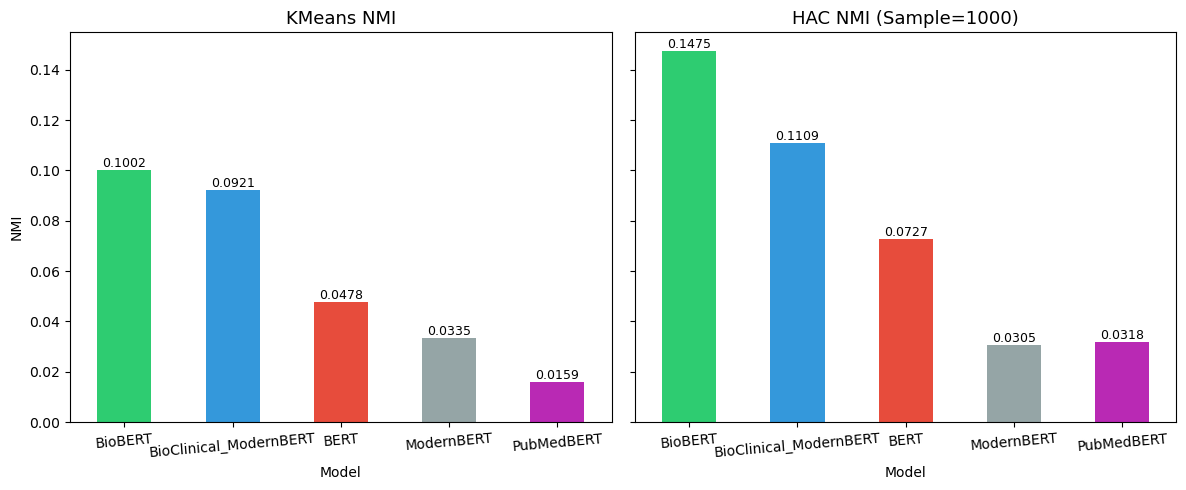

In [184]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharey=True)

# KMeans plot
summary_df.set_index("Model")["KMeans_NMI"].plot(kind="bar",ax=axes[0], color=["#2ecc71", "#3498db", "#e74c3c", "#95a5a6",  "#b929b4"])
axes[0].set_title("KMeans NMI", fontsize=13)
axes[0].set_xlabel("Model")
axes[0].set_ylabel("NMI")
axes[0].tick_params(axis="x", rotation=5)

for i in axes[0].containers:
    axes[0].bar_label(i, fontsize=9)

# HAC plot
summary_df.set_index("Model")["HAC_NMI"].plot(kind="bar",ax=axes[1], color=["#2ecc71", "#3498db", "#e74c3c", "#95a5a6",  "#b929b4"])
axes[1].set_title("HAC NMI (Sample=1000)", fontsize=13)
axes[1].set_xlabel("Model")
axes[1].set_ylabel("NMI")
axes[1].tick_params(axis="x", rotation=5)

for i in axes[1].containers:
    axes[1].bar_label(i, fontsize=9)

plt.tight_layout()
plt.show()

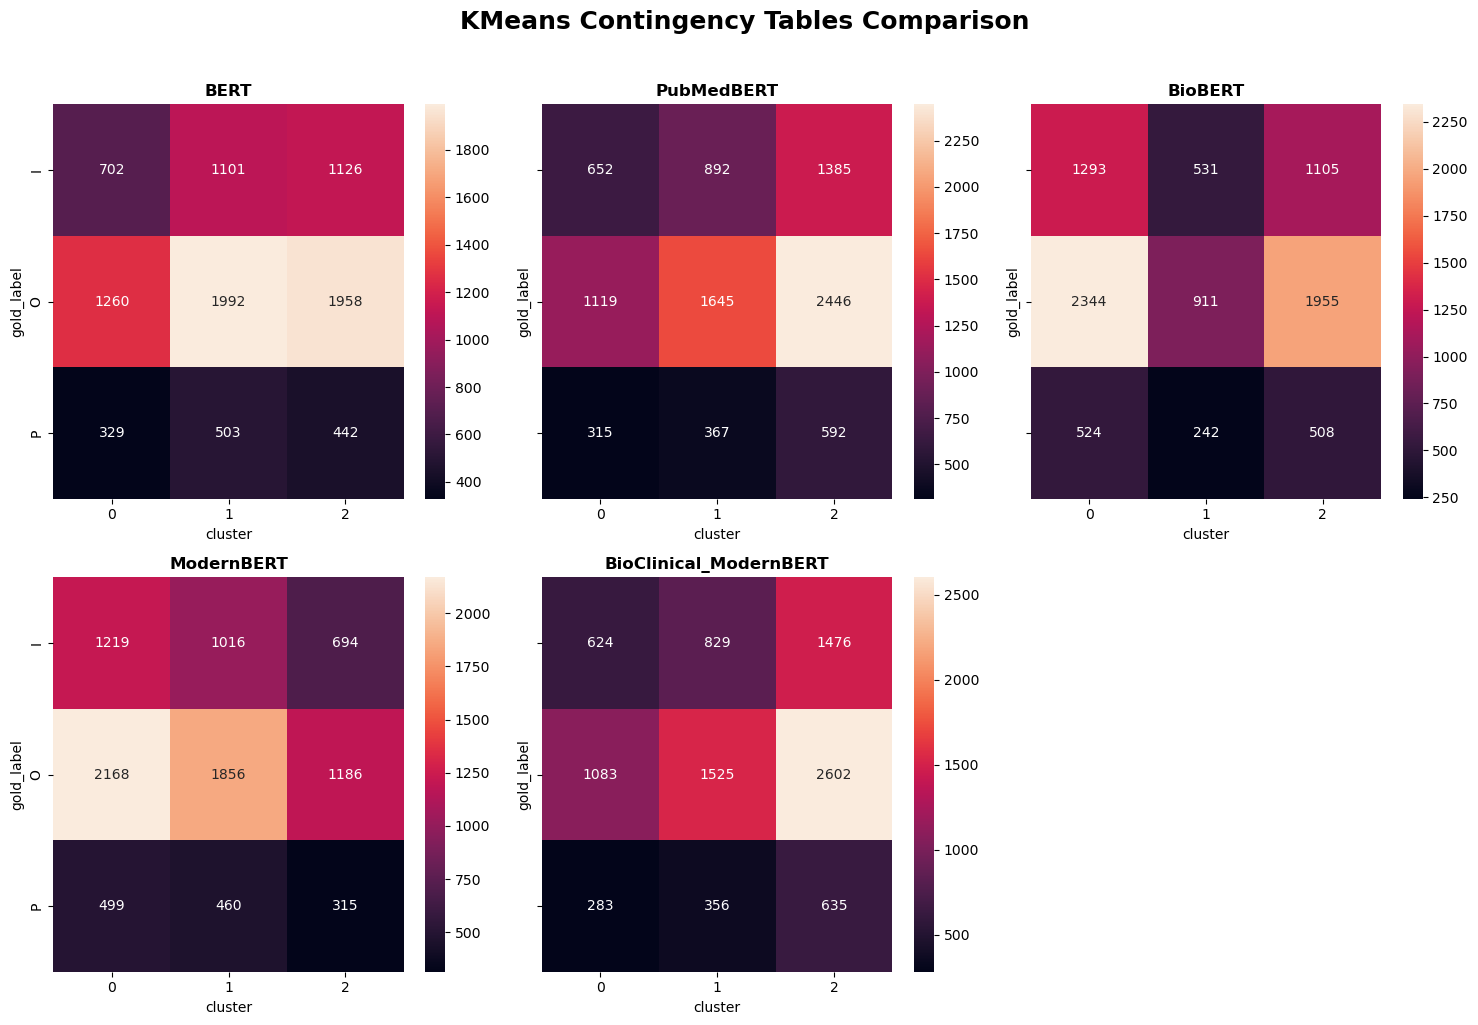

In [185]:
fig, axes = plt.subplots(2, 3, figsize=(15,10), sharey=True)
fig.suptitle("KMeans Contingency Tables Comparison", fontsize=18, fontweight='bold', y=1.02)
axes = axes.flatten()

sns.heatmap(result_bert["KMeans_Contingency_Tables"], annot=True, fmt="d", ax=axes[0])
axes[0].set_title("BERT",fontweight='bold')

sns.heatmap(result_pub["KMeans_Contingency_Tables"], annot=True, fmt="d", ax=axes[1])
axes[1].set_title("PubMedBERT",fontweight='bold')

sns.heatmap(result_bio["KMeans_Contingency_Tables"], annot=True, fmt="d", ax=axes[2])
axes[2].set_title("BioBERT",fontweight='bold')

sns.heatmap(result_mod_bert["KMeans_Contingency_Tables"], annot=True, fmt="d", ax=axes[3])
axes[3].set_title("ModernBERT",fontweight='bold')

sns.heatmap(result_biocli_mod_bert["KMeans_Contingency_Tables"], annot=True, fmt="d", ax=axes[4])
axes[4].set_title("BioClinical_ModernBERT",fontweight='bold')

axes[5].axis('off')

plt.tight_layout()
plt.show()


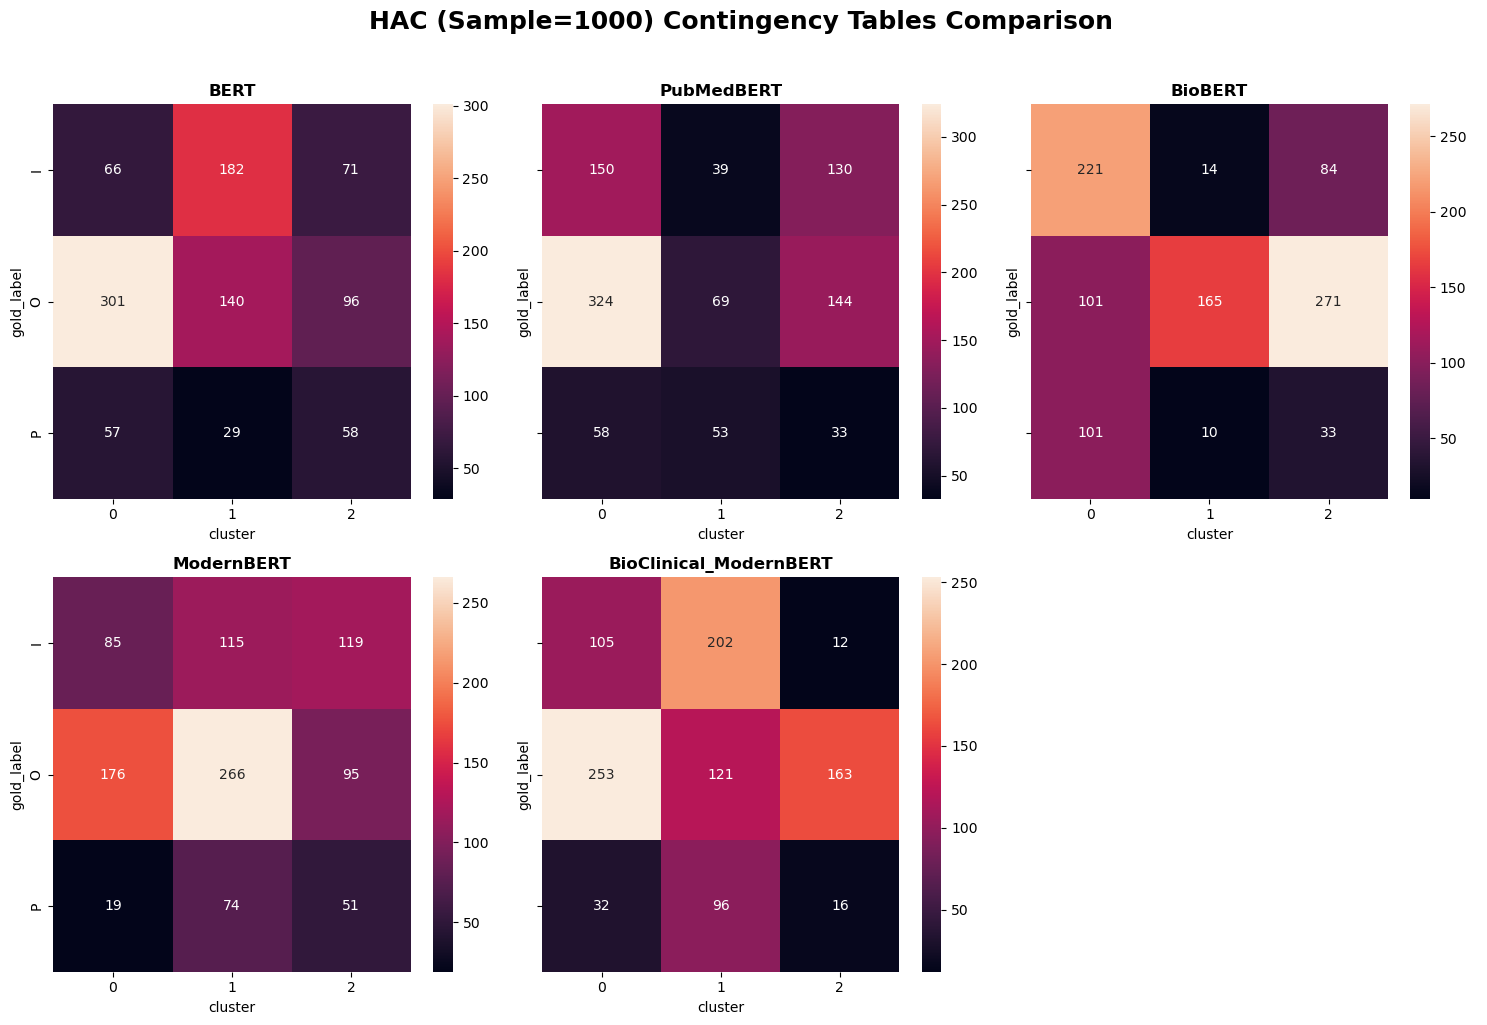

In [186]:
fig, axes = plt.subplots(2, 3, figsize=(15,10), sharey=True)
fig.suptitle("HAC (Sample=1000) Contingency Tables Comparison ", fontsize=18, fontweight='bold', y=1.02)
axes = axes.flatten()

sns.heatmap(result_bert["HAC_Contingency_Tables"], annot=True, fmt="d", ax=axes[0])
axes[0].set_title("BERT",fontweight='bold')

sns.heatmap(result_pub["HAC_Contingency_Tables"], annot=True, fmt="d", ax=axes[1])
axes[1].set_title("PubMedBERT",fontweight='bold')

sns.heatmap(result_bio["HAC_Contingency_Tables"], annot=True, fmt="d", ax=axes[2])
axes[2].set_title("BioBERT",fontweight='bold')

sns.heatmap(result_mod_bert["HAC_Contingency_Tables"], annot=True, fmt="d", ax=axes[3])
axes[3].set_title("ModernBERT",fontweight='bold')

sns.heatmap(result_biocli_mod_bert["HAC_Contingency_Tables"], annot=True, fmt="d", ax=axes[4])
axes[4].set_title("BioClinical_ModernBERT",fontweight='bold')

axes[5].axis('off')

plt.tight_layout()
plt.show()


Even with domain specific encoders (BioBERT,PubMedBERT BioClinical ModernBERT), clusters are not clearly separated by P/I/O. This is expected because P/I/O labels reflect the role of a sentence (participant/intervention/outcome) rather than topical similarity, and sentence embeddings tend to organize texts primarily by semantic topic and writing style. As a result, large mixed clusters emerge, especially under class imbalance (Outcomes dominating and Participants being sparse). This motivates moving from unsupervised clustering to task-specific fine-tuning for more reliable P/I/O discrimination.

### C) Embedding labels with supervised models (Sentence and Token-Level Fine-Tuned BioBERT, BioClinical_ModernBERT,and PubMedBERT)

In [221]:
# !pip install evaluate
# !pip install seqeval

import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from datasets import Dataset
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    AutoModelForTokenClassification,
    TrainingArguments,
    Trainer,
    DataCollatorWithPadding,
    DataCollatorForTokenClassification
)

# seqeval is used later for token-level BIO evaluation (span-level F1)
import evaluate
seqeval = evaluate.load("seqeval")

import os
import torch

from transformers.trainer_utils import get_last_checkpoint
from datasets import disable_progress_bar
disable_progress_bar()

os.environ["PYTORCH_MPS_HIGH_WATERMARK_RATIO"] = "0.0"

if torch.backends.mps.is_available():
    torch.mps.empty_cache()

#### Sentence-level fine-tuning setup (P/I/O sentence-level classification)

In [ ]:
# Sentence-level fine-tuning setup (P/I/O sentence-level classification)

# Prepare dataset for final evaluation
eval_sentence_dataset = sentence_test_records_df[["doc_id","sentence_text"]].copy().dropna().reset_index(drop=True)

# Prepare P/I/O dataset
train_df = train_pio[["sentence_text", "gold_label"]].copy()
test_df  = test_pio[["sentence_text", "gold_label"]].copy()

# Encode labels P/I/O into integer
le = LabelEncoder()
train_df["label_id"] = le.fit_transform(train_df["gold_label"])
test_df["label_id"]  = le.transform(test_df["gold_label"])

# Train and validation split (stratified for class proportions)
X_train, X_val, y_train, y_val = train_test_split(
    train_df["sentence_text"].tolist(),
    train_df["label_id"].tolist(),
    test_size=0.2,
    random_state=42,
    stratify=train_df["label_id"],
)

# Test split
X_test = test_df["sentence_text"].tolist()
y_test = test_df["label_id"].tolist()

print("Label mapping:", dict(zip(le.classes_, le.transform(le.classes_))))
print("Sizes:", len(X_train), len(X_val), len(X_test))

# Models to be compared (sentence-level fine-tuning)
MODELS_FT = {
    "BioBERT": "dmis-lab/biobert-base-cased-v1.2",
    "BioClinical_ModernBERT": "thomas-sounack/BioClinical-ModernBERT-base",
    "PubMedBERT": "microsoft/BiomedNLP-PubMedBERT-base-uncased-abstract",
}

# Metrics for sentence classification (accuracy + macro-F1
acc = evaluate.load("accuracy")
f1  = evaluate.load("f1")

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=-1)
    return {
        "accuracy": acc.compute(predictions=preds, references=labels)["accuracy"],
        "macro_f1": f1.compute(predictions=preds, references=labels, average="macro")["f1"],
    }

def make_sentence_datasets(tokenizer, max_len=64):
    # Train, Validation, test dataset (with lables)
    train_dataset = Dataset.from_dict({"text": X_train, "labels": y_train})
    val_dataset   = Dataset.from_dict({"text": X_val,   "labels": y_val})
    test_dataset  = Dataset.from_dict({"text": X_test,  "labels": y_test})
 
    # Evaluation dataset for final evaluation (without labels)
    pred_dataset = Dataset.from_dict({"text": eval_sentence_dataset["sentence_text"].tolist()})

    def tokenize(batch):
        return tokenizer(batch["text"], truncation=True, padding="max_length", max_length=max_len)
        
    train_dataset = train_dataset.map(tokenize, batched=True)
    val_dataset   = val_dataset.map(tokenize, batched=True)
    test_dataset  = test_dataset.map(tokenize, batched=True)
    pred_dataset = pred_dataset.map(tokenize, batched=True)

    # Set torch format for Trainer
    cols = ["input_ids", "attention_mask", "labels"]
    train_dataset.set_format(type="torch", columns=cols)
    val_dataset.set_format(type="torch", columns=cols)
    test_dataset.set_format(type="torch", columns=cols)

    pred_dataset.set_format(type="torch", columns=["input_ids", "attention_mask"])


    return train_dataset, val_dataset, test_dataset, eval_sentence_dataset, pred_dataset


Label mapping: {'I': np.int64(0), 'O': np.int64(1), 'P': np.int64(2)}
Sizes: 15567 3892 846


In [204]:
# Sentence-level fine-tuning setup (P/I/O sentence-level classification)

# Output folder
os.makedirs("../outputs/Axis1B/finetune_axis1B", exist_ok=True) # stores model checkpoints
os.makedirs("../outputs", exist_ok=True) # stores final doc-level prediction CSVs

# Collects model's test metrics for a final comparison table
all_sentence_results = []

def run_finetuning(tag, verbose=True, export_eval_csv=True):
    model_name = MODELS_FT[tag]
    output_dir = f"../outputs/Axis1B/finetune_axis1B/{tag}"

    print("\n===========================================")
    print("P/I/O only Fine-tuning results:", tag)
    print("===========================================")

    # Load tokenizer
    tokenizer = AutoTokenizer.from_pretrained(model_name)
    
    # Dynamic padding to reduce compute waste
    data_collator = DataCollatorWithPadding(tokenizer=tokenizer)

    # Train and validation split
    train_dataset, val_dataset, test_dataset, eval_df, pred_dataset = make_sentence_datasets(tokenizer, max_len=64)

    # If a previous checkpoint exists, reuse. If not, run the model
    os.makedirs(output_dir, exist_ok=True)
    last_checkpoint = get_last_checkpoint(output_dir) if os.path.isdir(output_dir) else None
    is_trained = last_checkpoint is not None or os.path.exists(os.path.join(output_dir, "config.json"))

    if is_trained:
        load_path = last_checkpoint if last_checkpoint else output_dir
        model = AutoModelForSequenceClassification.from_pretrained(load_path)

    else:
        model = AutoModelForSequenceClassification.from_pretrained(model_name, num_labels=len(le.classes_))

     # Training configuration
    training_args = TrainingArguments(
        output_dir=f"../outputs/Axis1B/finetune_axis1B/{tag}",
        eval_strategy="epoch",
        save_strategy="epoch", # for quick test "no" else "epoch"
        load_best_model_at_end=True, # for quick test "False" else "True"
        metric_for_best_model="macro_f1",
        greater_is_better=True,

        learning_rate=2e-5,
        per_device_train_batch_size=4,
        per_device_eval_batch_size=8,
        gradient_accumulation_steps=2,
        gradient_checkpointing=False, # for quick test "False" else "True"
        num_train_epochs=2, # for quick test "1" else "2"
        weight_decay=0.01,

        logging_steps=200,
        save_total_limit=1, 
        disable_tqdm=True,
        report_to="none",
    )

    trainer = Trainer(
        model=model,
        args=training_args,
        train_dataset=train_dataset,
        eval_dataset=val_dataset,
        processing_class=tokenizer,
        data_collator=data_collator,
        compute_metrics=compute_metrics,
    )

    # Train only if it is not trained(saved)
    if not is_trained:
        trainer.train()
        trainer.save_model(output_dir)
        
# Evaluate on test set
    test_metrics = trainer.evaluate(test_dataset)
    if verbose:
            print("Test metrics:", test_metrics)

    # Metrics for summary table
    result = {"Model": tag, **test_metrics}
    all_sentence_results.append(result)

    # Optional: export predictions on eval_sentence_dataset
    if export_eval_csv:
        pred = trainer.predict(pred_dataset)
        out_path = f"../outputs/axis1B_{tag}_pred.csv"
        export_pred_csv(eval_df, pred.predictions, le, out_path, sep=";")

    return trainer, test_dataset, result


def export_pred_csv(eval_df, pred_logits, label_encoder, out_path, sep=";"):
    
    # logits -> predicted class id (0,1,2) -> predicted class label (I,O,P)
    pred_id = np.argmax(pred_logits, axis=-1)
    pred_label = label_encoder.inverse_transform(pred_id)
    
    df = eval_df.copy()
    df["pred_label"] = pred_label

    # For each doc_id and predicted label, concatenate the corresponding sentence_text
    grouped = (
        df.groupby(["doc_id", "pred_label"])["sentence_text"]
          .apply(lambda x: sep.join(x.tolist()))
          .unstack(fill_value="")
          .reset_index()
    )

    out = pd.DataFrame({
        "doc_id": grouped["doc_id"],
        "participants_pred": grouped["P"] if "P" in grouped.columns else "",
        "interventions_pred": grouped["I"] if "I" in grouped.columns else "",
        "outcomes_pred": grouped["O"] if "O" in grouped.columns else "",
    }).fillna("")

    out.to_csv(out_path, index=False)
    print("Saved:", out_path, out.shape, "| docs:", out["doc_id"].nunique())
    return out

#### Token-level fine-tuning setup (P/I/O token-level classification)

In [ ]:
# Token-level fine-tuning setup (P/I/O token-level classification)

import os, numpy as np, pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.utils import resample

from datasets import Dataset
from transformers import (
    AutoTokenizer,
    AutoModelForTokenClassification,
    TrainingArguments,
    Trainer,
)
import evaluate
# Span-level precision/recall/F1 for BIO tagging
seqeval = evaluate.load("seqeval")

# BIO label mapping for token classification
LABEL_MAPPING = {"O": 0, "B": 1, "I": 2}
ID_MAPPING = {0: "O", 1: "B", 2: "I"}

# Build token-level dataset
token_train_df = sentence_records_df[["doc_id","sentence_id","sentence_tokens","p_bio","i_bio","o_bio"]].dropna().reset_index(drop=True)
token_test_df  = sentence_test_records_df[["doc_id","sentence_id","sentence_tokens","p_bio","i_bio","o_bio"]].dropna().reset_index(drop=True)

# True if the span has positive entity token (B/I)
def ensure_list(x):
    return eval(x) if isinstance(x, str) else x

# String -> list
def has_positive_bio(bio_seq):
    bio_seq = ensure_list(bio_seq)
    return any(t != "O" for t in bio_seq)

# "1" if the span has positive entity token (B/I) for stratification in train/val split, else "0"
def make_any_positive_label(df):
    return (
        df["p_bio"].apply(has_positive_bio) |
        df["i_bio"].apply(has_positive_bio) |
        df["o_bio"].apply(has_positive_bio)
    ).astype(int)

# Make stratify label
y_any = make_any_positive_label(token_train_df)

# Stratified train/val split
token_train_df, token_val_df = train_test_split(token_train_df, test_size=0.2, random_state=42, stratify=y_any)

# Check positive sentence rate
def positive_sentence_rate(df, bio_col):
    s = df[bio_col].dropna().apply(has_positive_bio)
    return float(s.mean()) if len(s) else 0.0

# Check B/I rate
def token_bi_ratio(df, bio_col):
    total = 0
    bi = 0

    for seq in df[bio_col].dropna().tolist():
        seq = ensure_list(seq)  # str -> list 처리
        total += len(seq)
        bi += sum(1 for t in seq if t in ("B", "I"))

    return (bi / total) if total > 0 else 0.0

# For train dataset, to handle class imbalance, downsample sentences containing "O"  and oversample sentences containing "B/I"
def balance_train_df(df, bio_col, pos_mult=3, neg_keep=0.5, seed=42):

    df = df.dropna().reset_index(drop=True).copy()

    pos = df[df[bio_col].apply(has_positive_bio)]
    neg = df[~df[bio_col].apply(has_positive_bio)]

    pos_before = len(pos)
    neg_before = len(neg)

    # If negative("O"), downsample
    if 0 < neg_keep < 1.0 and neg_before > 0:
        neg = neg.sample(frac=neg_keep, random_state=seed)
    neg_after = len(neg)

    # If positive("B/I"), oversample
    if pos_mult > 1 and pos_before > 0:
        pos_up = resample(pos, replace=True, n_samples=pos_before * pos_mult, random_state=seed)
    else:
        pos_up = pos
    pos_after = len(pos_up)

    out = pd.concat([neg, pos_up], ignore_index=True).sample(frac=1, random_state=seed).reset_index(drop=True)
 
    stats = {
        "bio_col": bio_col,
        "pos_before": pos_before,
        "pos_after": pos_after,
        "neg_before": neg_before,
        "neg_after": neg_after,
        "out_n": len(out),
        "pos_mult": pos_mult,
        "neg_keep": neg_keep
    }

    return out, stats

In [ ]:
train_bal_P, stats_P = balance_train_df(token_train_df, "p_bio", pos_mult=3, neg_keep=0.5, seed=42)
train_bal_I, stats_I = balance_train_df(token_train_df, "i_bio", pos_mult=3, neg_keep=0.5, seed=42)
train_bal_O, stats_O = balance_train_df(token_train_df, "o_bio", pos_mult=3, neg_keep=0.5, seed=42)

# BEFORE
print("B/I ratio BEFORE handling class imbalance")
for col in ["p_bio","i_bio","o_bio"]:
    bi = token_bi_ratio(token_train_df, col)
    print(col, f"BI={bi:.4f} | non-BI(O)={1.0 - bi:.4f}")

# AFTER
print("\nB/I ratio AFTER handling class imbalance")
bi = token_bi_ratio(train_bal_P, "p_bio")
print("p_bio:", f"BI={bi:.4f} | non-BI(O)={1.0 - bi:.4f}")

bi = token_bi_ratio(train_bal_I, "i_bio")
print("i_bio:", f"BI={bi:.4f} | non-BI(O)={1.0 - bi:.4f}")

bi = token_bi_ratio(train_bal_O, "o_bio")
print("o_bio:", f"BI={bi:.4f} | non-BI(O)={1.0 - bi:.4f}")

print("\nSampling size changes")
for s in [stats_P, stats_I, stats_O]:
    print(
        f"{s['bio_col']}: "
        f"pos {s['pos_before']} -> {s['pos_after']}, "
        f"neg {s['neg_before']} -> {s['neg_after']}, "
        f"out={s['out_n']}"
    )

B/I ratio BEFORE handling class imbalance
p_bio BI=0.0465 | non-BI(O)=0.9535
i_bio BI=0.0705 | non-BI(O)=0.9295
o_bio BI=0.0965 | non-BI(O)=0.9035

B/I ratio AFTER handling class imbalance (field-specific)
p_bio: BI=0.1213 | non-BI(O)=0.8787
i_bio: BI=0.1291 | non-BI(O)=0.8709
o_bio: BI=0.1685 | non-BI(O)=0.8315

Sampling size changes
p_bio: pos 8267 -> 24801, neg 25717 -> 12858, out=37659
i_bio: pos 14147 -> 42441, neg 19837 -> 9918, out=52359
o_bio: pos 15092 -> 45276, neg 18892 -> 9446, out=54722


In [ ]:
# NER with transformers
# Build dataset for token classification (BIO tagging)
# Tokenize then align BIO labels to subword tokens

def make_token_dataset(df, tokenizer, bio_col, max_len=64, include_labels=True):
    rows = []
    
    for r in df.to_dict("records"):
        tokens = ensure_list(r["sentence_tokens"])

        # Word tokens -> subword tokens
        enc = tokenizer(tokens, is_split_into_words=True, truncation=True, padding="max_length", max_length=max_len)

        if include_labels:
            bio = ensure_list(r[bio_col])
            word_ids = enc.word_ids()

            # Align BIO labels to subword
            aligned = []
            prev_w = None
            for w in word_ids:
                if w is None:
                    aligned.append(-100)
                else:
                    lab = bio[w]

                    if w != prev_w:
                        aligned.append(LABEL_MAPPING[lab])
                    else:
                        aligned.append(LABEL_MAPPING["I"] if lab == "B" else LABEL_MAPPING[lab])
                prev_w = w

            enc["labels"] = aligned

        rows.append(enc)

    token_dataset = Dataset.from_list(rows)
    if include_labels:
        token_dataset.set_format(type="torch", columns=["input_ids","attention_mask","labels"])
    else:
        token_dataset.set_format(type="torch", columns=["input_ids","attention_mask"])
    return token_dataset

# Compute span-level precision/recall/F1 using seqeval
def compute_metrics_token(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=-1)

    true_labels, true_preds = [], []
    for p, l in zip(preds, labels):
        sent_l, sent_p = [], []
        for pi, li in zip(p, l):
            if li == -100:
                continue
            # Gold BIO label
            sent_l.append(ID_MAPPING[int(li)])
            # Predicted BIO label
            sent_p.append(ID_MAPPING[int(pi)])
        true_labels.append(sent_l)
        true_preds.append(sent_p)

    scores = seqeval.compute(predictions=true_preds, references=true_labels)
    return {
        "precision": scores["overall_precision"],
        "recall": scores["overall_recall"],
        "f1": scores["overall_f1"],
    }

In [207]:
# !pip install nltk

import re
from nltk.tokenize.treebank import TreebankWordDetokenizer
untoken = TreebankWordDetokenizer()

# tokens -> text
def untokenize_tokens(tokens):
    return untoken.detokenize(tokens)

# Remove empty, short, punctuations only spans and stop words
PUNCT_ONLY_RE     = re.compile(r"^[\W_]+$") # only punctuation/symbols
ONLY_BRACKETS_RE  = re.compile(r"^[\[\]\(\)\{\}]+$") # only brackets
HAS_ALNUM_RE      = re.compile(r"[A-Za-z0-9]") # at least one letter/digit
DIGITS_ONLY_RE    = re.compile(r"^\d+(\.\d+)?$") # only digits
STOPWORDS = {
    "the","a","an","and","or","of","to","in","on","for","with","at","by","from",
    "is","are","was","were","be","been","being","as","that","this","these","those",
    "it","its","their","there","which","who","whom","than","then","but","if","while",
    "vs","v"
}

def clean_span_text(text, min_chars=2, drop_pure_numbers=False, drop_stopwords=True):
    if text is None:
        return ""

    t = text.strip()
    if not t:
        return ""
    # remove punctuation/bracket-only spans
    if PUNCT_ONLY_RE.match(t) or ONLY_BRACKETS_RE.match(t):
        return ""
    # remove at least one alphanumeric char
    if HAS_ALNUM_RE.search(t) is None:
        return ""
    # remove short char
    if len(t) < min_chars:
        return ""
    # remove pure-number spans
    if drop_pure_numbers and DIGITS_ONLY_RE.match(t):
        return ""
    # remove single-topken stopword
    if drop_stopwords:
        toks = t.lower().split()
        if len(toks) == 1 and toks[0] in STOPWORDS:
            return ""
    
    return t

# Freeze all transformer layers except the classification head for quick test. 
def freeze_head_only(model):
    for name, p in model.named_parameters():
        if "classifier" not in name:
            p.requires_grad = False

# Decoding Predicted BIO index -> span index ranges
def spans_from_bio_ids(ids):
    spans = []
    start = None
    for i, t in enumerate(ids):
        if t == 1:  # B starts a new span
            if start is not None:
                spans.append((start, i))
            start = i
        elif t == 2:  # I continues a span
            if start is None:
                start = i
        else:  # O closes a span
            if start is not None:
                spans.append((start, i))
                start = None
    if start is not None:
        spans.append((start, len(ids)))
    return spans

# Sentence-level logits -> doc-level field text 
def extract_doc_field_from_logits(df_eval, pred_logits, out_col, sep="; "):
    pred_ids = np.argmax(pred_logits, axis=-1)
    rows = []

    for (doc_id, toks), ids in zip(df_eval[["doc_id","sentence_tokens"]].values, pred_ids):
        toks = ensure_list(toks)
        ids  = ids[:len(toks)]

        spans = spans_from_bio_ids(ids)

        span_texts = []
        for a, b in spans:
            s = untokenize_tokens(toks[a:b])
            s = clean_span_text(s)
            if s:
                span_texts.append(s)

        rows.append((doc_id, sep.join(span_texts)))

    # Merge all sentence-level outputs into one row per doc_id
    out = pd.DataFrame(rows, columns=["doc_id", out_col])
    out = out.groupby("doc_id")[out_col].apply(lambda xs: sep.join([x for x in xs if x])).reset_index()
    return out

# Merge P/I/O doc-level outputs and extract evaluation CSV
def export_pred_csv_from_logits(tag, predP, predI, predO, out_path, sep="; "):
    eval_token_df = token_test_df[["doc_id","sentence_tokens"]].copy()

    P = extract_doc_field_from_logits(eval_token_df, predP, "participants_pred", sep=sep)
    I = extract_doc_field_from_logits(eval_token_df, predI, "interventions_pred", sep=sep)
    O = extract_doc_field_from_logits(eval_token_df, predO, "outcomes_pred", sep=sep)

    out = P.merge(I, on="doc_id", how="outer").merge(O, on="doc_id", how="outer").fillna("")
    out.to_csv(out_path, index=False)
    return out


In [ ]:
MODELS = {
    "BioBERT": "dmis-lab/biobert-base-cased-v1.2",
    "BioClinical_ModernBERT": "thomas-sounack/BioClinical-ModernBERT-base",
    "PubMedBERT": "microsoft/BiomedNLP-PubMedBERT-base-uncased-abstract",
}

all_token_results = []

# Train a token classifier for ONE field (P or I or O) using BIO tags.
def train_one_field(
    tag,
    bio_col,
    token_train_df,
    token_val_df,
    token_test_df,
    MODELS,
    pos_mult=3, # To handle class imbalance, oversample positive sentences (those containing B/I tags) by multiplying this much (3)
    neg_keep=0.5, # To handle class imbalance, downsample negative sentences (O tag) by keeping this fraction (0.5)
    max_len=64,
    finetune_mode="full",
    seed=42,
    verbose=True,
    export_eval_csv=True
):
    
    model_name = MODELS[tag]
    output_dir = f"../outputs/Axis1B/finetune_axis1B/{tag}_{bio_col}"
    os.makedirs(output_dir, exist_ok=True)

    tokenizer = AutoTokenizer.from_pretrained(model_name, use_fast=True)
    data_collator = DataCollatorForTokenClassification(tokenizer=tokenizer)
    
    # balance train data
    train_df_bal = balance_train_df(token_train_df, bio_col, pos_mult=pos_mult, neg_keep=neg_keep, seed=seed)

    # build datasets with subword label alignment
    train_token_dataset = make_token_dataset(train_df_bal, tokenizer, bio_col, max_len = max_len, include_labels = True)
    val_token_dataset   = make_token_dataset(token_val_df, tokenizer, bio_col, max_len = max_len, include_labels = True)
    test_token_dataset  = make_token_dataset(token_test_df, tokenizer, bio_col, max_len = max_len, include_labels = True)
    
    pred_eval_df = token_test_df[["doc_id","sentence_tokens"]].dropna().reset_index(drop=True)

    pred_token_dataset  = make_token_dataset(pred_eval_df, tokenizer, bio_col, max_len = max_len, include_labels=False)

    # train (or load checkpoint)
    last_checkpoint = get_last_checkpoint(output_dir)
    is_trained = last_checkpoint is not None or os.path.exists(os.path.join(output_dir, "config.json"))

    if is_trained:
        load_path = last_checkpoint if last_checkpoint else output_dir
        model = AutoModelForTokenClassification.from_pretrained(load_path)
    
    else:    
        model = AutoModelForTokenClassification.from_pretrained(
        model_name,
        num_labels=3,
        id2label=ID_MAPPING,
        label2id=LABEL_MAPPING
    )

    # Freeze all transformer layers except the classification head
    if finetune_mode == "head":
        freeze_head_only(model)

    args = TrainingArguments(
        output_dir=f"../outputs/Axis1B/finetune_axis1B/{tag}_{bio_col}",
        eval_strategy="epoch",
        save_strategy="epoch", # for quick test "no" else "epoch"
        load_best_model_at_end=True, # for quick test "False" else "True"
        metric_for_best_model="f1",
        greater_is_better=True,
        learning_rate=2e-5,
        per_device_train_batch_size=4,
        # Token-level tagging is more memory-intensive than sentence classification, so use smaller evaluation batches and no gradient accumulation for stability
        per_device_eval_batch_size=4,
        gradient_accumulation_steps=1,
        gradient_checkpointing=False,  # for quick test "False" else "True"
        num_train_epochs=2, # for quick test "1" else "2"
        weight_decay=0.01,
        logging_steps=200,
        save_total_limit=1, 
        disable_tqdm=True,
        report_to="none",
    )

    trainer = Trainer(
        model=model, 
        args=args, 
        train_dataset=train_token_dataset, 
        eval_dataset=val_token_dataset,
        processing_class=tokenizer,
        data_collator=data_collator,
        compute_metrics=compute_metrics_token,
    )

    if not is_trained:
        trainer.train()
        trainer.save_model(output_dir)

 # Evaluate on test split
    test_metrics = trainer.evaluate(test_token_dataset)

    if verbose:
            print("Test metrics:", test_metrics)

    result = {"Model": tag, **test_metrics}
    all_token_results.append(result)

    # Predict BIO logits aligned with pred_eval_df row order
    pred_logits = trainer.predict(pred_token_dataset).predictions

    return pred_logits, test_metrics, pred_eval_df

#### Run Sentence-level models (BioBERT, BioClinical_ModernBERT,and PubMedBERT)

In [211]:
# Run sentence-level P/I/O models (BioBERT)
all_sentence_results = []

trainer_bio, test_dataset_bio, result_ft_bio = run_finetuning("BioBERT",verbose=False)


P/I/O only Fine-tuning results: BioBERT


Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

/opt/miniconda3/envs/text_analytics/lib/python3.14/site-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  super().__init__(loader)


{'eval_loss': '0.4479', 'eval_model_preparation_time': '0.0013', 'eval_accuracy': '0.8664', 'eval_macro_f1': '0.8653', 'eval_runtime': '4.773', 'eval_samples_per_second': '177.2', 'eval_steps_per_second': '22.21'}


/opt/miniconda3/envs/text_analytics/lib/python3.14/site-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  super().__init__(loader)


Saved: ../outputs/axis1B_BioBERT_pred.csv (178, 4) | docs: 178


In [212]:
# Run sentence-level P/I/O models (BioClinical_ModernBERT)
trainer_biocli, test_dataset_biocli, result_ft_biocli = run_finetuning("BioClinical_ModernBERT", verbose=False)


P/I/O only Fine-tuning results: BioClinical_ModernBERT


Loading weights:   0%|          | 0/138 [00:00<?, ?it/s]

/opt/miniconda3/envs/text_analytics/lib/python3.14/site-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  super().__init__(loader)


{'eval_loss': '0.511', 'eval_model_preparation_time': '0.0029', 'eval_accuracy': '0.8582', 'eval_macro_f1': '0.8458', 'eval_runtime': '8.599', 'eval_samples_per_second': '98.38', 'eval_steps_per_second': '12.33'}


/opt/miniconda3/envs/text_analytics/lib/python3.14/site-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  super().__init__(loader)


Saved: ../outputs/axis1B_BioClinical_ModernBERT_pred.csv (178, 4) | docs: 178


In [213]:
# Run sentence-level P/I/O models (PubMedBERT)
trainer_pub, test_dataset_pub, result_ft_pub = run_finetuning("PubMedBERT", verbose=False)


P/I/O only Fine-tuning results: PubMedBERT


Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

/opt/miniconda3/envs/text_analytics/lib/python3.14/site-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  super().__init__(loader)


{'eval_loss': '0.4562', 'eval_model_preparation_time': '0.0012', 'eval_accuracy': '0.883', 'eval_macro_f1': '0.8775', 'eval_runtime': '4.867', 'eval_samples_per_second': '173.8', 'eval_steps_per_second': '21.78'}


/opt/miniconda3/envs/text_analytics/lib/python3.14/site-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  super().__init__(loader)


Saved: ../outputs/axis1B_PubMedBERT_pred.csv (178, 4) | docs: 178


#### Run token-level models (BioBERT, BioClinical_ModernBERT,and PubMedBERT)

In [216]:
# Run token-level P/I/O models (BioBERT)

all_token_results = []

os.makedirs("../outputs", exist_ok=True)

# Train one token tagger per field (P/I/O)
predP_bio, metP_bio, eval_df_bio = train_one_field(
    tag="BioBERT",
    bio_col="p_bio",
    token_train_df=token_train_df,
    token_val_df=token_val_df,
    token_test_df=token_test_df,
    MODELS=MODELS,
    finetune_mode="full",   # quick sanity; switch to "full" for final
    verbose=False
)

predI_bio, metI_bio, eval_df_bio2 = train_one_field(
    tag="BioBERT",
    bio_col="i_bio",
    token_train_df=token_train_df,
    token_val_df=token_val_df,
    token_test_df=token_test_df,
    MODELS=MODELS,
    finetune_mode="full",
    verbose=False
)

predO_bio, metO_bio, eval_df_bio3 = train_one_field(
    tag="BioBERT",
    bio_col="o_bio",
    token_train_df=token_train_df,
    token_val_df=token_val_df,
    token_test_df=token_test_df,
    MODELS=MODELS,
    finetune_mode="full",
    verbose=False
)

assert eval_df_bio.shape[0] == eval_df_bio2.shape[0] == eval_df_bio3.shape[0]

df_pred_bio = export_pred_csv_from_logits(
    "BioBERT",
    predP_bio, predI_bio, predO_bio,
    out_path="../outputs/axis1B_BioBERT_pred.csv",
    sep="; "
)

[balance_train_df:p_bio] pos=8267 neg=12858 -> out=37659 (pos_mult=3, neg_keep=0.5)


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

/opt/miniconda3/envs/text_analytics/lib/python3.14/site-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  super().__init__(loader)


{'eval_loss': '0.2181', 'eval_model_preparation_time': '0.0009', 'eval_precision': '0.1644', 'eval_recall': '0.2812', 'eval_f1': '0.2075', 'eval_runtime': '12.57', 'eval_samples_per_second': '155.9', 'eval_steps_per_second': '38.98'}
[balance_train_df:i_bio] pos=14147 neg=9918 -> out=52359 (pos_mult=3, neg_keep=0.5)


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

/opt/miniconda3/envs/text_analytics/lib/python3.14/site-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  super().__init__(loader)


{'eval_loss': '0.1578', 'eval_model_preparation_time': '0.0013', 'eval_precision': '0.5048', 'eval_recall': '0.6634', 'eval_f1': '0.5733', 'eval_runtime': '12.31', 'eval_samples_per_second': '159.2', 'eval_steps_per_second': '39.79'}
[balance_train_df:o_bio] pos=15092 neg=9446 -> out=54722 (pos_mult=3, neg_keep=0.5)


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

/opt/miniconda3/envs/text_analytics/lib/python3.14/site-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  super().__init__(loader)


{'eval_loss': '0.2677', 'eval_model_preparation_time': '0.001', 'eval_precision': '0.351', 'eval_recall': '0.4853', 'eval_f1': '0.4074', 'eval_runtime': '12.06', 'eval_samples_per_second': '162.5', 'eval_steps_per_second': '40.61'}


In [218]:
# Run token-level P/I/O models (BioClinical_ModernBERT)

predP_biocli, metP_biocli, eval_df_biocli = train_one_field(
    tag="BioClinical_ModernBERT",
    bio_col="p_bio",
    token_train_df=token_train_df,
    token_val_df=token_val_df,
    token_test_df=token_test_df,
    MODELS=MODELS,
    finetune_mode="full", # for quick test "head" else "full"
    verbose=False
)

predI_biocli, metI_biocli, eval_df_biocli2 = train_one_field(
    tag="BioClinical_ModernBERT",
    bio_col="i_bio",
    token_train_df=token_train_df,
    token_val_df=token_val_df,
    token_test_df=token_test_df,
    MODELS=MODELS,
    finetune_mode="full",
    verbose=False
)

predO_biocli, metO_biocli, eval_df_biocli3 = train_one_field(
    tag="BioClinical_ModernBERT",
    bio_col="o_bio",
    token_train_df=token_train_df,
    token_val_df=token_val_df,
    token_test_df=token_test_df,
    MODELS=MODELS,
    finetune_mode="full",
    verbose=False
)

assert eval_df_biocli.shape[0] == eval_df_biocli2.shape[0] == eval_df_biocli3.shape[0]

df_pred_biocli = export_pred_csv_from_logits(
    "BioClinical_ModernBERT",
    predP_biocli, predI_biocli, predO_biocli,
    out_path="../outputs/axis1B_BioClinical_ModernBERT_pred.csv",
    sep="; "
)

[balance_train_df:p_bio] pos=8267 neg=12858 -> out=37659 (pos_mult=3, neg_keep=0.5)


Loading weights:   0%|          | 0/136 [00:00<?, ?it/s]

ModernBertForTokenClassification LOAD REPORT from: thomas-sounack/BioClinical-ModernBERT-base
Key               | Status     | 
------------------+------------+-
decoder.bias      | UNEXPECTED | 
classifier.weight | MISSING    | 
classifier.bias   | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.
The tokenizer has new PAD/BOS/EOS tokens that differ from the model config and generation config. The model config and generation config were aligned accordingly, being updated with the tokenizer's values. Updated tokens: {'eos_token_id': None, 'bos_token_id': None}.
/opt/miniconda3/envs/text_analytics/lib/python3.14/site-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  s

{'loss': '0.383', 'grad_norm': '3.128', 'learning_rate': '1.979e-05', 'epoch': '0.02124'}
{'loss': '0.302', 'grad_norm': '1.696', 'learning_rate': '1.958e-05', 'epoch': '0.04249'}
{'loss': '0.2404', 'grad_norm': '1.264', 'learning_rate': '1.936e-05', 'epoch': '0.06373'}
{'loss': '0.2615', 'grad_norm': '5.444', 'learning_rate': '1.915e-05', 'epoch': '0.08497'}
{'loss': '0.237', 'grad_norm': '2.648', 'learning_rate': '1.894e-05', 'epoch': '0.1062'}
{'loss': '0.2412', 'grad_norm': '6.674', 'learning_rate': '1.873e-05', 'epoch': '0.1275'}
{'loss': '0.2496', 'grad_norm': '3.053', 'learning_rate': '1.851e-05', 'epoch': '0.1487'}
{'loss': '0.236', 'grad_norm': '1.472', 'learning_rate': '1.83e-05', 'epoch': '0.1699'}
{'loss': '0.2133', 'grad_norm': '2.807', 'learning_rate': '1.809e-05', 'epoch': '0.1912'}
{'loss': '0.215', 'grad_norm': '1.708', 'learning_rate': '1.788e-05', 'epoch': '0.2124'}
{'loss': '0.1835', 'grad_norm': '1.213', 'learning_rate': '1.766e-05', 'epoch': '0.2337'}
{'loss': '0.

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

{'train_runtime': '6132', 'train_samples_per_second': '17.85', 'train_steps_per_second': '4.462', 'train_loss': '0.1247', 'epoch': '2'}


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

/opt/miniconda3/envs/text_analytics/lib/python3.14/site-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  super().__init__(loader)


{'eval_loss': '0.2129', 'eval_precision': '0.3571', 'eval_recall': '0.4777', 'eval_f1': '0.4087', 'eval_runtime': '23.63', 'eval_samples_per_second': '82.94', 'eval_steps_per_second': '20.73', 'epoch': '2'}


In [217]:
# Run token-level P/I/O models (PubMedBERT)

predP_pub, metP_pub, eval_df_pub = train_one_field(
    tag="PubMedBERT",
    bio_col="p_bio",
    token_train_df=token_train_df,
    token_val_df=token_val_df,
    token_test_df=token_test_df,
    MODELS=MODELS,
    finetune_mode="full", # for quick test "head" else "full"
    verbose=False
)

predI_pub, metI_pub, eval_df_pub2 = train_one_field(
    tag="PubMedBERT",
    bio_col="i_bio",
    token_train_df=token_train_df,
    token_val_df=token_val_df,
    token_test_df=token_test_df,
    MODELS=MODELS,
    finetune_mode="full",
    verbose=False
)

predO_pub, metO_pub, eval_df_pub3 = train_one_field(
    tag="PubMedBERT",
    bio_col="o_bio",
    token_train_df=token_train_df,
    token_val_df=token_val_df,
    token_test_df=token_test_df,
    MODELS=MODELS,
    finetune_mode="full",
    verbose=False
)

assert eval_df_pub.shape[0] == eval_df_pub2.shape[0] == eval_df_pub3.shape[0]

df_pred_pub = export_pred_csv_from_logits(
    "PubMedBERT",
    predP_pub, predI_pub, predO_pub,
    out_path="../outputs/axis1B_PubMedBERT_pred.csv",
    sep="; "
)

[balance_train_df:p_bio] pos=8267 neg=12858 -> out=37659 (pos_mult=3, neg_keep=0.5)


Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

BertForTokenClassification LOAD REPORT from: microsoft/BiomedNLP-PubMedBERT-base-uncased-abstract
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.decoder.bias               | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.decoder.weight             | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
bert.pooler.dense.weight                   | UNEXPECTED | 
bert.pooler.dense.bias                     | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPEC

{'loss': '0.3386', 'grad_norm': '6.582', 'learning_rate': '1.979e-05', 'epoch': '0.02124'}
{'loss': '0.285', 'grad_norm': '7.336', 'learning_rate': '1.958e-05', 'epoch': '0.04249'}
{'loss': '0.2306', 'grad_norm': '2.643', 'learning_rate': '1.936e-05', 'epoch': '0.06373'}
{'loss': '0.2466', 'grad_norm': '5.04', 'learning_rate': '1.915e-05', 'epoch': '0.08497'}
{'loss': '0.2343', 'grad_norm': '10.25', 'learning_rate': '1.894e-05', 'epoch': '0.1062'}
{'loss': '0.2277', 'grad_norm': '15.51', 'learning_rate': '1.873e-05', 'epoch': '0.1275'}
{'loss': '0.2539', 'grad_norm': '6.716', 'learning_rate': '1.851e-05', 'epoch': '0.1487'}
{'loss': '0.2362', 'grad_norm': '3.942', 'learning_rate': '1.83e-05', 'epoch': '0.1699'}
{'loss': '0.2092', 'grad_norm': '5.392', 'learning_rate': '1.809e-05', 'epoch': '0.1912'}
{'loss': '0.2217', 'grad_norm': '2.549', 'learning_rate': '1.788e-05', 'epoch': '0.2124'}
{'loss': '0.1844', 'grad_norm': '2.59', 'learning_rate': '1.766e-05', 'epoch': '0.2337'}
{'loss': '

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

...

There were missing keys in the checkpoint model loaded: ['bert.embeddings.LayerNorm.weight', 'bert.embeddings.LayerNorm.bias', 'bert.encoder.layer.0.attention.output.LayerNorm.weight', 'bert.encoder.layer.0.attention.output.LayerNorm.bias', 'bert.encoder.layer.0.output.LayerNorm.weight', 'bert.encoder.layer.0.output.LayerNorm.bias', 'bert.encoder.layer.1.attention.output.LayerNorm.weight', 'bert.encoder.layer.1.attention.output.LayerNorm.bias', 'bert.encoder.layer.1.output.LayerNorm.weight', 'bert.encoder.layer.1.output.LayerNorm.bias', 'bert.encoder.layer.2.attention.output.LayerNorm.weight', 'bert.encoder.layer.2.attention.output.LayerNorm.bias', 'bert.encoder.layer.2.output.LayerNorm.weight', 'bert.encoder.layer.2.output.LayerNorm.bias', 'bert.encoder.layer.3.attention.output.LayerNorm.weight', 'bert.encoder.layer.3.attention.output.LayerNorm.bias', 'bert.encoder.layer.3.output.LayerNorm.weight', 'bert.encoder.layer.3.output.LayerNorm.bias', 'bert.encoder.layer.4.attention.output.La

{'train_runtime': '4402', 'train_samples_per_second': '24.86', 'train_steps_per_second': '6.216', 'train_loss': '0.1383', 'epoch': '2'}


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

/opt/miniconda3/envs/text_analytics/lib/python3.14/site-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  super().__init__(loader)


{'eval_loss': '0.2167', 'eval_precision': '0.3574', 'eval_recall': '0.4989', 'eval_f1': '0.4165', 'eval_runtime': '11.71', 'eval_samples_per_second': '167.4', 'eval_steps_per_second': '41.84', 'epoch': '2'}


### Summary table for Sentence and Token-level models (BioBERT, BioClinical_ModernBERT,and PubMedBERT)

#### Sentence-level P/I/O Classification Results

In [ ]:
# Sentence-level P/I/O Classification Results

summary_df = pd.DataFrame(all_sentence_results)[
    ["Model", "eval_loss", "eval_accuracy", "eval_macro_f1"] # Runtime-related values in this table reflect test-set evaluation time after loading saved checkpoints, rather than full training time. Therefore, they are not used for the main comparison of model efficiency.
].rename(columns={
    "eval_loss": "Loss",
    "eval_accuracy": "Accuracy",
    "eval_macro_f1": "Macro-F1"
})
summary_df

,Model,Loss,Accuracy,Macro-F1
0,BioBERT,0.447908,0.866430,0.865320
1,BioClinical_ModernBERT,0.510965,0.858156,0.845844
2,PubMedBERT,0.456191,0.882979,0.877513


#### Sentence-level Error Analysis

In [ ]:
# Classification report and Confusion matrix for sentence-level finetuning

from sklearn.metrics import classification_report, confusion_matrix
import numpy as np

pred_bio = trainer_bio.predict(test_dataset_bio)
y_pred_bio = np.argmax(pred_bio.predictions, axis=-1)

print("\nClassification report for BioBERT:")
#print(classification_report(pred_bio.label_ids, y_pred_bio, target_names=le.classes_))
report_dict_bio = classification_report(pred_bio.label_ids, y_pred_bio, target_names=le.classes_, output_dict=True)
report_df_bio = pd.DataFrame(report_dict_bio).T
print(report_df_bio)

print("\nConfusion matrix for BioBERT:")
print(confusion_matrix(pred_bio.label_ids, y_pred_bio))

pred_biocli = trainer_biocli.predict(test_dataset_biocli)
y_pred_biocli = np.argmax(pred_biocli.predictions, axis=-1)

print("\nClassification report for BioClinical_ModernBERT:")
#print(classification_report(pred_bio.label_ids, y_pred_bio, target_names=le.classes_))
report_dict_biocli = classification_report(pred_biocli.label_ids, y_pred_biocli, target_names=le.classes_, output_dict=True)
report_df_biocli = pd.DataFrame(report_dict_biocli).T
print(report_df_biocli)

print("\nConfusion matrix for BioClinical_ModernBERT:")
print(confusion_matrix(pred_biocli.label_ids, y_pred_biocli))

pred_pub = trainer_pub.predict(test_dataset_pub)
y_pred_pub = np.argmax(pred_pub.predictions, axis=-1)

print("\n\n\nClassification report for PubMedBERT:")
#print(classification_report(pred_pub.label_ids, y_pred_pub, target_names=le.classes_))
report_dict_pub = classification_report(pred_pub.label_ids, y_pred_pub, target_names=le.classes_, output_dict=True)
report_df_pub = pd.DataFrame(report_dict_pub).T
report_df_pub
print(report_df_pub)

print("\nConfusion matrix for PubMedBERT:")
print(confusion_matrix(pred_pub.label_ids, y_pred_pub))

/opt/miniconda3/envs/text_analytics/lib/python3.14/site-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  super().__init__(loader)



Classification report for BioBERT:
              precision    recall  f1-score    support
I              0.849624  0.782007  0.814414  289.00000
O              0.870044  0.916473  0.892655  431.00000
P              0.888889  0.888889  0.888889  126.00000
accuracy       0.866430  0.866430  0.866430    0.86643
macro avg      0.869519  0.862456  0.865320  846.00000
weighted avg   0.865875  0.866430  0.865367  846.00000

Confusion matrix for BioBERT:
[[226  56   7]
 [ 29 395   7]
 [ 11   3 112]]


/opt/miniconda3/envs/text_analytics/lib/python3.14/site-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  super().__init__(loader)



Classification report for BioClinical_ModernBERT:
              precision    recall  f1-score     support
I              0.873950  0.719723  0.789374  289.000000
O              0.855950  0.951276  0.901099  431.000000
P              0.837209  0.857143  0.847059  126.000000
accuracy       0.858156  0.858156  0.858156    0.858156
macro avg      0.855703  0.842714  0.845844  846.000000
weighted avg   0.859308  0.858156  0.854884  846.000000

Confusion matrix for BioClinical_ModernBERT:
[[208  64  17]
 [ 17 410   4]
 [ 13   5 108]]


/opt/miniconda3/envs/text_analytics/lib/python3.14/site-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  super().__init__(loader)





Classification report for PubMedBERT:
              precision    recall  f1-score     support
I              0.900794  0.785467  0.839187  289.000000
O              0.872068  0.948956  0.908889  431.000000
P              0.888000  0.880952  0.884462  126.000000
accuracy       0.882979  0.882979  0.882979    0.882979
macro avg      0.886954  0.871792  0.877513  846.000000
weighted avg   0.884254  0.882979  0.881440  846.000000

Confusion matrix for PubMedBERT:
[[227  53   9]
 [ 17 409   5]
 [  8   7 111]]


For sentence-level classification, the models are evaluated using Accuracy and Macro-F1(primary metric due to class imbalance across P/I/O). Furthermore, classification report and confusion matrix was also reported to check which and where the labeling error mostly happened.

#### Token-level P/I/O Span Tagging(BIO) Results

In [219]:
# summary table for token-level finetuning

def get_metric(m, key):
    return m.get(f"eval_{key}", m.get(key, np.nan))

token_rows = []

# BioBERT result
token_rows.append({
    "Model": "BioBERT",
    "P_F1": get_metric(metP_bio, "f1"),
    "P_Precision": get_metric(metP_bio, "precision"),
    "P_Recall": get_metric(metP_bio, "recall"),
    "I_F1": get_metric(metI_bio, "f1"),
    "I_Precision": get_metric(metI_bio, "precision"),
    "I_Recall": get_metric(metI_bio, "recall"),
    "O_F1": get_metric(metO_bio, "f1"),
    "O_Precision": get_metric(metO_bio, "precision"),
    "O_Recall": get_metric(metO_bio, "recall"),
    "Avg_F1": np.nanmean([get_metric(metP_bio, "f1"), get_metric(metI_bio, "f1"), get_metric(metO_bio, "f1")]),
})

# BioClinical_ModernBERT result
token_rows.append({
    "Model": "BioClinical_ModernBERT",
    "P_F1": get_metric(metP_biocli, "f1"),
    "P_Precision": get_metric(metP_biocli, "precision"),
    "P_Recall": get_metric(metP_biocli, "recall"),
    "I_F1": get_metric(metI_biocli, "f1"),
    "I_Precision": get_metric(metI_biocli, "precision"),
    "I_Recall": get_metric(metI_biocli, "recall"),
    "O_F1": get_metric(metO_biocli, "f1"),
    "O_Precision": get_metric(metO_biocli, "precision"),
    "O_Recall": get_metric(metO_biocli, "recall"),
    "Avg_F1": np.nanmean([get_metric(metP_biocli, "f1"), get_metric(metI_biocli, "f1"), get_metric(metO_biocli, "f1")]),
})

# PubMedBERT result
token_rows.append({
    "Model": "PubMedBERT",
    "P_F1": get_metric(metP_pub, "f1"),
    "P_Precision": get_metric(metP_pub, "precision"),
    "P_Recall": get_metric(metP_pub, "recall"),
    "I_F1": get_metric(metI_pub, "f1"),
    "I_Precision": get_metric(metI_pub, "precision"),
    "I_Recall": get_metric(metI_pub, "recall"),
    "O_F1": get_metric(metO_pub, "f1"),
    "O_Precision": get_metric(metO_pub, "precision"),
    "O_Recall": get_metric(metO_pub, "recall"),
    "Avg_F1": np.nanmean([get_metric(metP_pub, "f1"), get_metric(metI_pub, "f1"), get_metric(metO_pub, "f1")]),
})

token_summary_df = pd.DataFrame(token_rows).sort_values("Avg_F1", ascending=False)
token_summary_df

,Model,P_F1,P_Precision,P_Recall,I_F1,I_Precision,I_Recall,O_F1,O_Precision,O_Recall,Avg_F1
2,PubMedBERT,0.206621,0.165751,0.274242,0.615240,0.560934,0.681189,0.416454,0.357417,0.498854,0.412772
0,BioBERT,0.207515,0.164444,0.281155,0.573350,0.504844,0.663366,0.407383,0.351004,0.485340,0.396083
1,BioClinical_ModernBERT,0.219117,0.173298,0.297872,0.527233,0.472920,0.595640,0.408701,0.357143,0.477658,0.385017


For token-level classification, SeqEval span-level Precision/Recall/F1 report was used to evaluate the models.